In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

TICKER   = "ZAMAUSDT"
DATES    = ["2026-04-12", "2026-04-13", "2026-04-14"]
DATA_DIR = Path("../task_data") / TICKER

## 1. Tick Rule — Algorithm

| Condition | Label |
|---|---|
| Δprice > 0 (uptick) | `False` — buy aggressor |
| Δprice < 0 (downtick) | `True` — sell aggressor |
| Δprice = 0 (zero-tick) | carry forward last non-zero tick |
| no prior non-zero tick | `None` — indeterminate |

In [2]:
all_trades = {
    date: pd.read_parquet(DATA_DIR / f"{TICKER}_trades_{date}.parquet")
    for date in DATES
}
{date: len(df) for date, df in all_trades.items()}

{'2026-04-12': 31162, '2026-04-13': 32408, '2026-04-14': 578015}

## 2. Multi-Day Evaluation

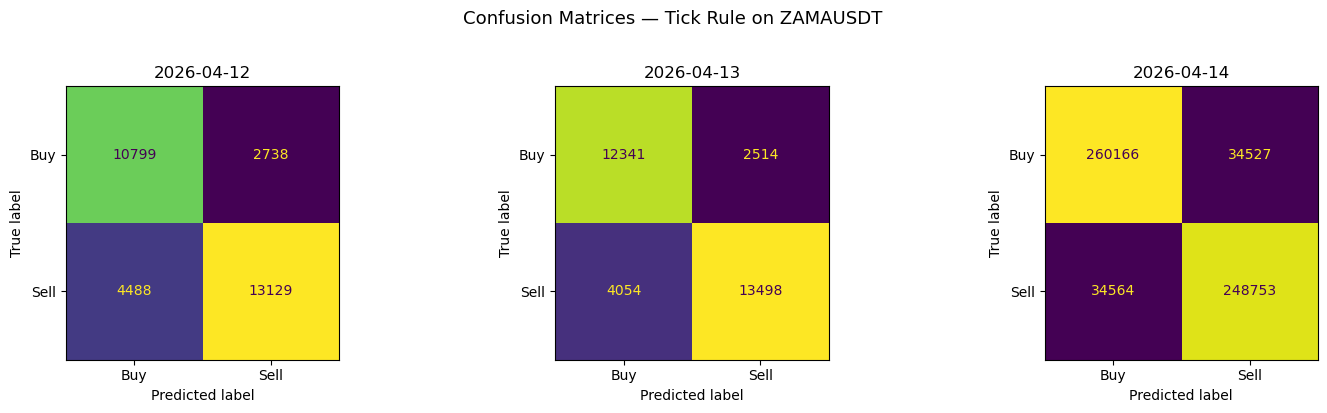

In [3]:
results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, date in zip(axes, DATES):
    trades = all_trades[date]
    tick_filled = np.sign(trades['price'].diff()).replace(0, np.nan).ffill()
    trade_side = pd.Series(
        np.select([tick_filled > 0, tick_filled < 0], [False, True], default=None),
        index=trades.index, name='predicted_trade_side'
    )
    final_df = pd.concat([trades[['price', 'side']], trade_side], axis=1).dropna()
    y_true = final_df['side'].astype(bool)
    y_pred  = final_df['predicted_trade_side'].astype(bool)
    results[date] = (y_true, y_pred, len(trades) - len(final_df))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=['Buy', 'Sell'], colorbar=False, ax=ax
    )
    ax.set_title(date)

fig.suptitle(f'Confusion Matrices — Tick Rule on {TICKER}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Per-Day Classification Reports

In [4]:
for date, (y_true, y_pred, indet) in results.items():
    print(f"\n=== {date}  (indeterminate: {indet}) ===")
    print(classification_report(y_true, y_pred, target_names=['Buy (False)', 'Sell (True)']))


=== 2026-04-12  (indeterminate: 8) ===
              precision    recall  f1-score   support

 Buy (False)       0.71      0.80      0.75     13537
 Sell (True)       0.83      0.75      0.78     17617

    accuracy                           0.77     31154
   macro avg       0.77      0.77      0.77     31154
weighted avg       0.77      0.77      0.77     31154


=== 2026-04-13  (indeterminate: 1) ===
              precision    recall  f1-score   support

 Buy (False)       0.75      0.83      0.79     14855
 Sell (True)       0.84      0.77      0.80     17552

    accuracy                           0.80     32407
   macro avg       0.80      0.80      0.80     32407
weighted avg       0.80      0.80      0.80     32407


=== 2026-04-14  (indeterminate: 5) ===
              precision    recall  f1-score   support

 Buy (False)       0.88      0.88      0.88    294693
 Sell (True)       0.88      0.88      0.88    283317

    accuracy                           0.88    578010
   macro

## 4. Summary

In [5]:
records = []
for date, (y_true, y_pred, indet) in results.items():
    r = classification_report(y_true, y_pred, target_names=['Buy', 'Sell'], output_dict=True)
    records.append({
        'Date': date, 'Samples': len(y_true), 'Indeterminate': indet,
        'Accuracy': r['accuracy'],
        'Buy F1': r['Buy']['f1-score'],
        'Sell F1': r['Sell']['f1-score'],
        'Macro F1': r['macro avg']['f1-score'],
    })

pd.DataFrame(records).set_index('Date').style \
    .format({'Accuracy': '{:.4f}', 'Buy F1': '{:.4f}', 'Sell F1': '{:.4f}', 'Macro F1': '{:.4f}'}) \
    .highlight_max(subset=['Accuracy', 'Buy F1', 'Sell F1', 'Macro F1'], color='lightgreen')

,Samples,Indeterminate,Accuracy,Buy F1,Sell F1,Macro F1
Date,,,,,,
2026-04-12,31154,8,0.7681,0.7493,0.7842,0.7668
2026-04-13,32407,1,0.7973,0.7898,0.8043,0.7971
2026-04-14,578010,5,0.8805,0.8828,0.8781,0.8804
